In [63]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
import re
import matplotlib.colors as mcolors

tactic_abbr_full = {
    "ttbp":"together_traverse_best_permutation",
    "dor":"divide_over_risks",
    "rndm":"random_walk",
    "hs":"horizontal_scan_traversal",
    "phs":"partitioned_horizontal_scan_traversal",
    "sp": "spiral_traversal_swarm",
    "lb": "lidbetter",
    "toq": "traverse_ordered_qa",
    "tpq":"traverse_p_qa",
    "dd":"discounted_distance",
    "ddr":"discounted_distance_reverse",
    "sl":"shared_list",
}



SUMMARY_FILENAME = '../data/dataset/sim_results_dataset.csv'

FIXED_HIDING_STRATEGY = 'random'
FIXED_NUMBER_OF_HIDERS = 2

FIXED_HIDING_CANDIDATES = 5
FIXED_GRID_WIDTH = 20
FIXED_NUMBER_OF_RUNS = 100000

results = {}

In [64]:
df_all = pd.read_csv(SUMMARY_FILENAME)


In [65]:
df_filtered = df_all[
    (df_all['hide_strategy'] == FIXED_HIDING_STRATEGY) &
    (df_all['n_hiders'] == FIXED_NUMBER_OF_HIDERS) &
    (df_all['n_hider_candidates'] == FIXED_HIDING_CANDIDATES) &
    (df_all['grid_width'] == FIXED_GRID_WIDTH) &
    (df_all['runs'] == FIXED_NUMBER_OF_RUNS)
]

all_swarm_sizes = sorted(df_filtered['swarm_size'].unique())

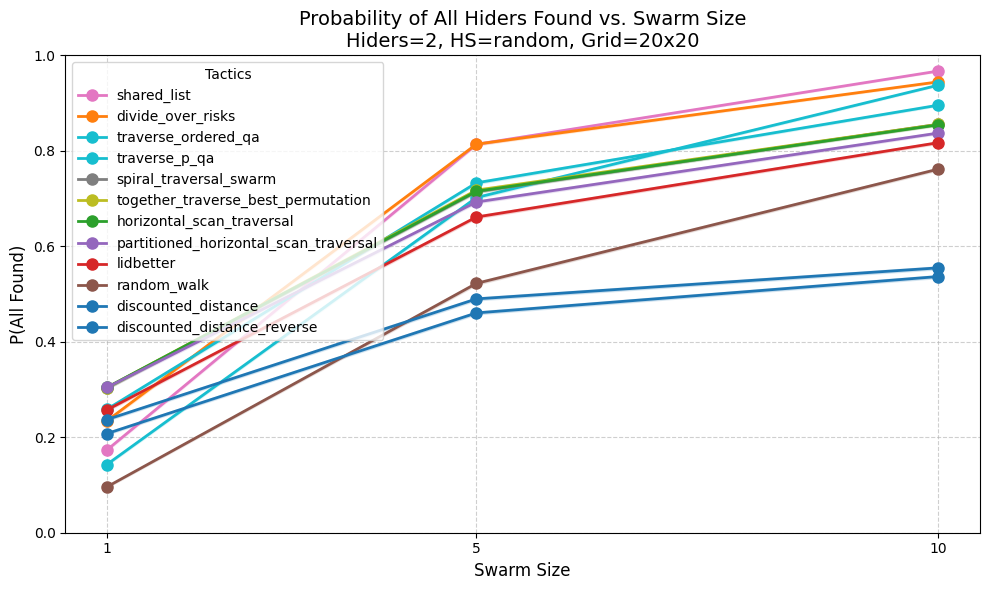

[('shared_list', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.17315, 0.81366, 0.96714]), 'low': array([0.17080934, 0.81123255, 0.96601645]), 'high': array([0.17550963, 0.81606924, 0.96823634])}), ('divide_over_risks', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.23431, 0.81392, 0.94449]), 'low': array([0.23168749, 0.81149384, 0.94305289]), 'high': array([0.23694793, 0.81632793, 0.94590126])}), ('traverse_ordered_qa', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.14289, 0.70212, 0.93759]), 'low': array([0.14072634, 0.69927468, 0.93607299]), 'high': array([0.14507439, 0.70495359, 0.93908157])}), ('traverse_p_qa', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.25853, 0.73293, 0.89565]), 'low': array([0.25581841, 0.73017612, 0.89373871]), 'high': array([0.26125561, 0.73567037, 0.89753831])}), ('spiral_traversal_swarm', {'swarm_sizes': array([ 1,  5, 10]), 'P': array([0.3033 , 0.71426, 0.85558]), 'low': array([0.30045164, 0.71144879, 0.85338602]), 'high': array([0.30615

In [66]:
for tactic_name in df_filtered['tactic'].unique():

    df_tactic = df_filtered[df_filtered['tactic'] == tactic_name]

    df_tactic = df_tactic.sort_values(by='swarm_size')

    results[tactic_name] = {
        'swarm_sizes': df_tactic['swarm_size'].values,
        'P':           df_tactic['all_found_mean'].values,
        'low':         df_tactic['all_found_ci_lower'].values,
        'high':        df_tactic['all_found_ci_upper'].values
    }

all_tactic_names = sorted(tactic_abbr_full.values())
colors_list = plt.cm.tab10(np.linspace(0, 1, len(all_tactic_names)))
tactic_colors = {tactic: color for tactic, color in zip(all_tactic_names, colors_list)}


sorted_results = sorted(
    results.items(),
    key=lambda item: item[1]['P'][-1] if len(item[1]['P']) > 0 else -1,
    reverse=True  # Highest P value first
)

plt.figure(figsize=(10, 6))
ax = plt.gca()


for i, (tactic_name, data) in enumerate(sorted_results):
    if not len(data['swarm_sizes']):
        print(f"{tactic_name} no data points")
        continue

    color = tactic_colors[tactic_name]

    ax.plot(
        data['swarm_sizes'],
        data['P'],
        label=tactic_name,
        color=color,
        linewidth=2,
        marker='o',
        markersize=8
    )


    ax.fill_between(
        data['swarm_sizes'],
        data['low'],
        data['high'],
        alpha=0.15,
        color=color,
        label=f'_{tactic_name}_CI' # Underscore hides from legend
    )

ax.set_xlabel('Swarm Size', fontsize=12)
ax.set_ylabel('P(All Found)', fontsize=12)
title = (
    f'Probability of All Hiders Found vs. Swarm Size\n'
    f'Hiders={FIXED_NUMBER_OF_HIDERS}, HS={FIXED_HIDING_STRATEGY}, '
    f'Grid={FIXED_GRID_WIDTH}x{FIXED_GRID_WIDTH}'
)
ax.set_title(title, fontsize=14)

ax.legend(loc='upper left', title='Tactics')

ax.set_ylim(0, 1)

ax.set_xticks(all_swarm_sizes)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

save_filename = (
    f'prob_all_found_vs_SwarmSize_'
    f'HS{FIXED_HIDING_STRATEGY}_H{FIXED_NUMBER_OF_HIDERS}.png'
)
# plt.savefig(save_filename)
# print(f"\nPlot saved to: {save_filename}")
plt.show()

print(sorted_results)

In [67]:
def generate_latex_table(results_object, caption, label):
    """
    Generates a formatted LaTeX table string from a results object.

    Args:
        results_object (list): A list of tuples, where each tuple is
            (tactic_name, data_dict). data_dict contains 'P', 'low', 'high'
            as lists or numpy arrays.
        caption (str): The LaTeX caption for the table.
        label (str): The LaTeX label for the table.
        tactic_order (list, optional): A list of tactic names in the order
            they should appear in the table. If None, it will default to
            a pre-defined order based on the example.

    Returns:
        str: A fully formatted LaTeX table as a string.
    """

    # This is the order of tactics as seen in your example tables.
    # We use this to ensure the rows are in the correct order.
    tactic_order = [tup[0] for tup in results_object]

    # Convert the input list of tuples into a dictionary for easy lookup
    data_dict = dict(results_object)

    # Find the maximum 'P' value for each column (swarm size)
    # We initialize with negative infinity to ensure any value is larger
    max_p = [-float('inf'), -float('inf'), -float('inf')]
    num_cols = 3 # Assumes 3 swarm sizes (1, 5, 10)

    for tactic_name in tactic_order:
        if tactic_name in data_dict:
            p_values = data_dict[tactic_name]['P']
            for i in range(num_cols):
                if p_values[i] > max_p[i]:
                    max_p[i] = p_values[i]

    # Start building the LaTeX string
    latex_lines = []
    latex_lines.append(r"\begin{table}[h]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\begin{tabular}{lccc}")
    latex_lines.append(r"\hline")
    latex_lines.append(r"\textbf{Tactic Name} & \textbf{Swarm size 1} & \textbf{Swarm size 5} & \textbf{Swarm size 10} \\")
    latex_lines.append(r"\hline")

    # Iterate through the tactics in the specified order to build rows
    for tactic_name in tactic_order:
        if tactic_name in data_dict:
            data = data_dict[tactic_name]
            P = data['P']
            low = data['low']
            high = data['high']

            # Escape underscores in tactic names for LaTeX
            latex_tactic_name = tactic_name.replace('_', r'\_')

            row_cols = [latex_tactic_name]

            # Format each column value
            for i in range(num_cols):
                val_str = f"{P[i]:.3f} [{low[i]:.3f}, {high[i]:.3f}]"

                # Add \textbf if this is the max value in the column
                if P[i] == max_p[i]:
                    row_cols.append(r"\textbf{" + val_str + r"}")
                else:
                    row_cols.append(val_str)

            # Join all columns with '&' and add the LaTeX line ending
            latex_lines.append(" & ".join(row_cols) + r" \\")

    # Add the table footer
    latex_lines.append(r"\hline")
    latex_lines.append(r"\end{tabular}")
    # Use f-string to insert the caption and label
    latex_lines.append(rf"\caption{{{caption}}}")
    latex_lines.append(rf"\label{{{label}}}")
    latex_lines.append(r"\end{table}")

    # Join all lines with a newline character and return
    return "\n".join(latex_lines)


caption = "Probability that all hiders were found, comparison across different swarm sizes for \\textbf{hiding strategy ",FIXED_HIDING_STRATEGY,"}, 2 hiders, 5 possible hiding spots and 20 x 20 grid."
label = f"tab:swarm_performance_{FIXED_HIDING_STRATEGY}"
latex_output = generate_latex_table(sorted_results, caption, label)
print(latex_output)


\begin{table}[h]
\centering
\begin{tabular}{lccc}
\hline
\textbf{Tactic Name} & \textbf{Swarm size 1} & \textbf{Swarm size 5} & \textbf{Swarm size 10} \\
\hline
shared\_list & 0.173 [0.171, 0.176] & 0.814 [0.811, 0.816] & \textbf{0.967 [0.966, 0.968]} \\
divide\_over\_risks & 0.234 [0.232, 0.237] & \textbf{0.814 [0.811, 0.816]} & 0.944 [0.943, 0.946] \\
traverse\_ordered\_qa & 0.143 [0.141, 0.145] & 0.702 [0.699, 0.705] & 0.938 [0.936, 0.939] \\
traverse\_p\_qa & 0.259 [0.256, 0.261] & 0.733 [0.730, 0.736] & 0.896 [0.894, 0.898] \\
spiral\_traversal\_swarm & 0.303 [0.300, 0.306] & 0.714 [0.711, 0.717] & 0.856 [0.853, 0.858] \\
together\_traverse\_best\_permutation & 0.304 [0.301, 0.307] & 0.718 [0.715, 0.720] & 0.855 [0.853, 0.858] \\
horizontal\_scan\_traversal & 0.304 [0.301, 0.307] & 0.715 [0.713, 0.718] & 0.854 [0.852, 0.857] \\
partitioned\_horizontal\_scan\_traversal & \textbf{0.304 [0.302, 0.307]} & 0.693 [0.690, 0.696] & 0.837 [0.835, 0.840] \\
lidbetter & 0.257 [0.255, 0.260] 

In [10]:
FIXED_SWARM_SIZE = 10

T_MIN = 0
T_MAX = 1000
T_STEP = 10
T_values = np.arange(T_MIN, T_MAX + T_STEP, T_STEP)
SIMLOGS = "../data/sim_logs/"

In [11]:
filename_pattern = re.compile(
    r"T-(.+)"                  # Group 1: TACTIC
    r"-W-(\d+)"                # Group 2: GRIDWIDTH
    r"-HS-(.+)"                # Group 3: HidingStrategy
    r"-D-(\d+)"                # Group 4: Swarmsize
    r"-C-(\d+)"                # Group 5: HidingCandidates
    r"-H-(\d+)"                # Group 6: NumberOfHiders
    r"-RUNS-(\d+)\.csv"        # Group 7: NumberOfRuns
)
results = {}
tactic_files_found = []

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:94: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Janvg\AppData\Local\Temp\ipykernel_33032\3317836312.py:25: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(SIMLOGS+filename, header=0, sep='\s+')
C:\Users\Janvg\AppData\Local\Temp\ipykernel_33032\3317836312.py:94: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('P(All Found | steps $\leq$ T)', fontsize=12)


Plot saved to: prob_all_found_vs_T_D10_HSgreedy.png


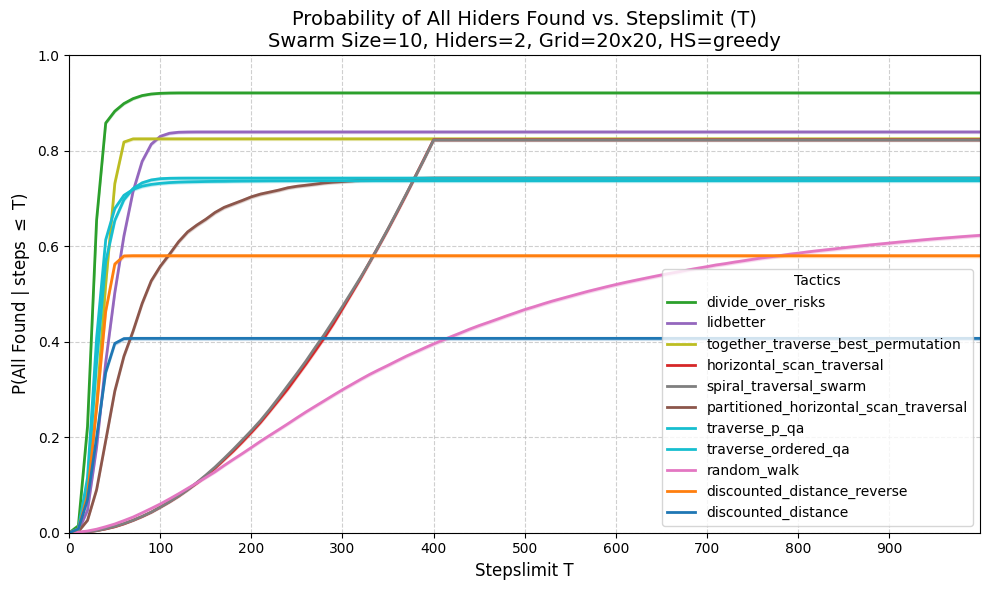

In [12]:
for filename in os.listdir(SIMLOGS):
    if not filename.endswith('.csv'):
        continue

    match = filename_pattern.match(filename)
    if not match:
        continue
    tactic = match.group(1)
    width = int(match.group(2))
    hs = match.group(3)
    swarm = int(match.group(4))
    candidates = int(match.group(5))
    hiders = int(match.group(6))
    runs = int(match.group(7))

    if (swarm == FIXED_SWARM_SIZE and
        hs == FIXED_HIDING_STRATEGY and
        candidates == FIXED_HIDING_CANDIDATES and
        hiders == FIXED_NUMBER_OF_HIDERS and
        width == FIXED_GRID_WIDTH and
        runs == FIXED_NUMBER_OF_RUNS):
        
        tactic_files_found.append(filename)

        df = pd.read_csv(SIMLOGS+filename, header=0, sep='\s+')

        successful_runs = df[df['all_found'] == True]

        probabilities = []
        ci_low = []
        ci_high = []

        for T in T_values:
            # Count successes *within* the step limit T
            # We filter the *already successful* runs for speed
            k_success_within_T = (successful_runs['steps'] <= T).sum()
            

            # k = number of successes (found all within T steps)

            result = binomtest(k=k_success_within_T, n=FIXED_NUMBER_OF_RUNS)
            
            probabilities.append(result.statistic)
            ci = result.proportion_ci()
            ci_low.append(ci.low)
            ci_high.append(ci.high)

        # Store results for this tactic
        results[tactic] = {
            'T': T_values,
            'P': probabilities,
            'low': ci_low,
            'high': ci_high
        }


all_tactic_names = sorted(tactic_abbr_full.values())

colors_list = plt.cm.tab10(np.linspace(0, 1, len(all_tactic_names)))
tactic_colors = {tactic: color for tactic, color in zip(all_tactic_names, colors_list)}

sorted_results = sorted(
    results.items(),
    key=lambda item: item[1]['P'][-1],
    reverse=True  # Highest P value first
)

plt.figure(figsize=(10, 6))
ax = plt.gca()

for i, (tactic_name, data) in enumerate(sorted_results):
    color = tactic_colors[tactic_name]
    
    # Plot the main probability line
    ax.plot(
        data['T'], 
        data['P'], 
        label=tactic_name, 
        color=color,
        linewidth=2
    )
    
    # Plot the confidence interval as a filled area
    ax.fill_between(
        data['T'], 
        data['low'], 
        data['high'], 
        alpha=0.2, 
        color=color,
        label=f'_{tactic_name}_CI' # Underscore hides from legend
    )

ax.set_xlabel('Stepslimit T', fontsize=12)
ax.set_ylabel('P(All Found | steps $\leq$ T)', fontsize=12)
title = (
    f'Probability of All Hiders Found vs. Stepslimit (T)\n'
    f'Swarm Size={FIXED_SWARM_SIZE}, Hiders={FIXED_NUMBER_OF_HIDERS}, '
    f'Grid={FIXED_GRID_WIDTH}x{FIXED_GRID_WIDTH}, HS={FIXED_HIDING_STRATEGY}'
)
ax.set_title(title, fontsize=14)
ax.legend(loc='lower right', title='Tactics')
ax.set_ylim(0, 1) 
ax.set_xlim(T_MIN, T_MAX)
ax.set_xticks(np.arange(T_MIN, T_MAX, 100))
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# plt.savefig(f'prob_all_found_vs_T_D{FIXED_SWARM_SIZE}_HS{FIXED_HIDING_STRATEGY}.png')
print(f"Plot saved to: prob_all_found_vs_T_D{FIXED_SWARM_SIZE}_HS{FIXED_HIDING_STRATEGY}.png")
plt.show()